In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Load Data

In [2]:
# Path to combined results file
data_file = Path("/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep/results_28nt/summaries/paramsweep_all.csv")

# Load data
if data_file.exists():
    df_all = pd.read_csv(data_file)
    print(f"Loaded data from: {data_file}")
    print(f"Total samples: {len(df_all)}")
    
    # Split by tool for individual analysis
    df_rb = df_all[df_all['tool'] == 'RandomBarcodes'].copy() if 'RandomBarcodes' in df_all['tool'].values else None
    df_quik = df_all[df_all['tool'] == 'QUIK'].copy() if 'QUIK' in df_all['tool'].values else None
    df_columba = df_all[df_all['tool'] == 'Columba'].copy() if 'Columba' in df_all['tool'].values else None
    
    print(f"RandomBarcodes samples: {len(df_rb) if df_rb is not None else 0}")
    print(f"QUIK samples: {len(df_quik) if df_quik is not None else 0}")
    print(f"Columba samples: {len(df_columba) if df_columba is not None else 0}")
else:
    print(f"ERROR: Data file not found: {data_file}")
    df_all = None
    df_rb = None
    df_quik = None
    df_columba = None

Loaded data from: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep/results_28nt/summaries/paramsweep_all.csv
Total samples: 47
RandomBarcodes samples: 24
QUIK samples: 18
Columba samples: 5


In [3]:
# Preview data
if df_all is not None:
    display(df_all.head(10))

,tool,sample_id,identity_threshold,nthresh,ntriage,rejection_threshold,strategy,total_reads,correct,incorrect,unassigned,assignment_rate,precision,recall,accuracy,f1_score
0,RandomBarcodes,RB_t10000_n10,NaN,10.0,10000.0,NaN,NaN,200000,165970,33948,82,99.9590,83.019038,82.9850,82.9850,83.002015
1,RandomBarcodes,RB_t10000_n5,NaN,5.0,10000.0,NaN,NaN,200000,72138,8,127854,36.0730,99.988911,36.0690,36.0690,53.014191
2,RandomBarcodes,RB_t10000_n6,NaN,6.0,10000.0,NaN,NaN,200000,105777,153,94070,52.9650,99.855565,52.8885,52.8885,69.151113
3,RandomBarcodes,RB_t10000_n7,NaN,7.0,10000.0,NaN,NaN,200000,129356,1503,69141,65.4295,98.851436,64.6780,64.6780,78.194034
4,RandomBarcodes,RB_t10000_n8,NaN,8.0,10000.0,NaN,NaN,200000,154219,9649,36132,81.9340,94.111724,77.1095,77.1095,84.766454
5,RandomBarcodes,RB_t10000_n9,NaN,9.0,10000.0,NaN,NaN,200000,164547,28803,6650,96.6750,85.103181,82.2735,82.2735,83.664421
6,RandomBarcodes,RB_t1000_n10,NaN,10.0,1000.0,NaN,NaN,200000,166171,33690,139,99.9305,83.143285,83.0855,83.0855,83.114382
7,RandomBarcodes,RB_t1000_n5,NaN,5.0,1000.0,NaN,NaN,200000,72138,8,127854,36.0730,99.988911,36.0690,36.0690,53.014191
8,RandomBarcodes,RB_t1000_n6,NaN,6.0,1000.0,NaN,NaN,200000,105777,153,94070,52.9650,99.855565,52.8885,52.8885,69.151113
9,RandomBarcodes,RB_t1000_n7,NaN,7.0,1000.0,NaN,NaN,200000,129354,1490,69156,65.4220,98.861239,64.6770,64.6770,78.196370


In [18]:
#df_all[(df_all['tool'] == 'QUIK') & (df_all['precision'] >= 99.9)]
tool = "Columba"
recall_threshold = 20
precision_threshold = 95
df_all[(df_all['tool'] == tool) & (df_all['recall'] >= recall_threshold) & (df_all['precision'] >= precision_threshold)]

,tool,sample_id,identity_threshold,nthresh,ntriage,rejection_threshold,strategy,total_reads,correct,incorrect,unassigned,assignment_rate,precision,recall,accuracy,f1_score
44,Columba,Columba_I77,77.0,NaN,NaN,NaN,NaN,1000000,570526,19687,409787,59.0213,96.6644,57.0526,57.0526,71.754658
45,Columba,Columba_I80,80.0,NaN,NaN,NaN,NaN,1000000,408431,1265,590304,40.9696,99.6912,40.8431,40.8431,57.945963
46,Columba,Columba_I83,83.0,NaN,NaN,NaN,NaN,1000000,281550,66,718384,28.1616,99.9766,28.1550,28.1550,43.936721


## 2. Summary Statistics

In [27]:
# Summary by tool
if df_all is not None:
    summary = df_all.groupby('tool')[['precision', 'recall', 'f1_score', 'assignment_rate']].agg(['mean', 'std', 'min', 'max'])
    print("\n=== Summary Statistics by Tool ===")
    display(summary)


=== Summary Statistics by Tool ===


precision                                     recall  \
                     mean       std        min        max       mean   
tool                                                                   
Columba         91.821680  9.612533  81.388100  99.976600  52.190220   
QUIK            93.076575  8.668459  73.064778  99.988369  64.569528   
RandomBarcodes  93.675719  6.975530  83.019038  99.988911  65.988687   

                                              f1_score                        \
                      std      min      max       mean        std        min   
tool                                                                           
Columba         17.290356  28.1550  67.4502  64.234086  13.132194  43.936721   
QUIK            12.413957  42.2975  78.0230  74.986858   8.019912  59.446678   
RandomBarcodes  17.423492  36.0690  83.1945  75.376045  11.570953  53.014191   

                          assignment_rate                               
                      max            mean        std      min      max  
tool                                                                    
Columba         73.766546       58.780420  24.575769  28.1616  82.8748  
QUIK            83.691748       70.813167  18.769781  42.3040  97.2485  
RandomBarcodes  85.004661       71.965021  23.360471  36.0730  99.9590

In [28]:
# Best configurations for each tool
if df_all is not None:
    print("\n=== Best Configuration by Tool (based on F1-score) ===")
    for tool in df_all['tool'].unique():
        tool_data = df_all[df_all['tool'] == tool]
        best = tool_data.loc[tool_data['f1_score'].idxmax()]
        print(f"\n{tool}:")
        print(f"  Sample: {best['sample_id']}")
        print(f"  Precision: {best['precision']:.2f}%")
        print(f"  Recall: {best['recall']:.2f}%")
        print(f"  F1-Score: {best['f1_score']:.2f}")
        print(f"  Assignment Rate: {best['assignment_rate']:.2f}%")


=== Best Configuration by Tool (based on F1-score) ===

RandomBarcodes:
  Sample: RB_t100_n8
  Precision: 95.13%
  Recall: 76.83%
  F1-Score: 85.00
  Assignment Rate: 80.76%

QUIK:
  Sample: QUIK_4mer_r8
  Precision: 95.75%
  Recall: 74.33%
  F1-Score: 83.69
  Assignment Rate: 77.63%

Columba:
  Sample: Columba_I72
  Precision: 81.39%
  Recall: 67.45%
  F1-Score: 73.77
  Assignment Rate: 82.87%


## 3. Overall Tool Comparison

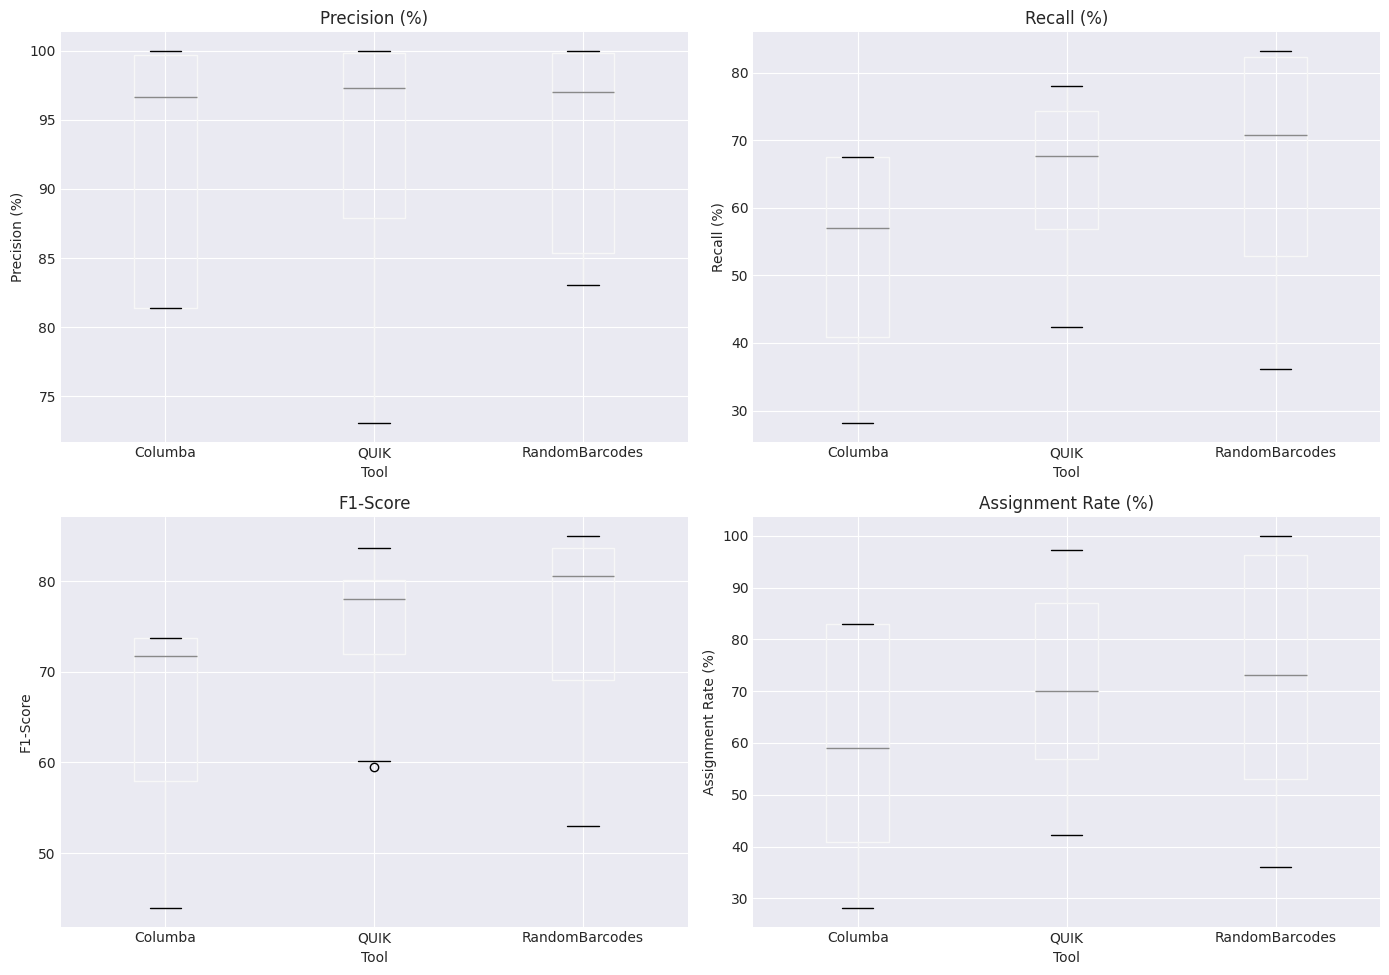

In [29]:
# Box plots comparing tools
if df_all is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = ['precision', 'recall', 'f1_score', 'assignment_rate']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score', 'Assignment Rate (%)']
    
    for ax, metric, title in zip(axes.flat, metrics, titles):
        df_all.boxplot(column=metric, by='tool', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Tool')
        ax.set_ylabel(title)
        ax.get_figure().suptitle('')
    
    plt.tight_layout()
    plt.savefig('figures/tool_comparison_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()

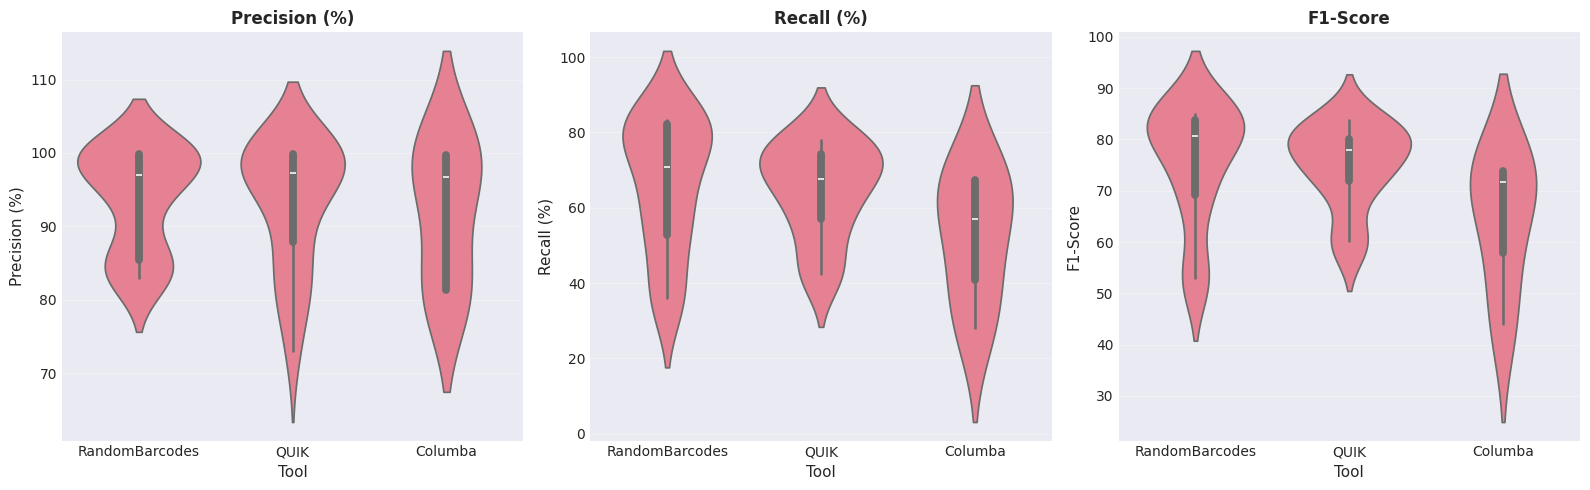

In [30]:
# Violin plots for better distribution visualization
if df_all is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, metric, title in zip(axes, ['precision', 'recall', 'f1_score'], 
                                  ['Precision (%)', 'Recall (%)', 'F1-Score']):
        sns.violinplot(data=df_all, x='tool', y=metric, ax=ax)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Tool', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/tool_comparison_violins.png', dpi=300, bbox_inches='tight')
    plt.show()

## 4. RandomBarcodes Parameter Analysis

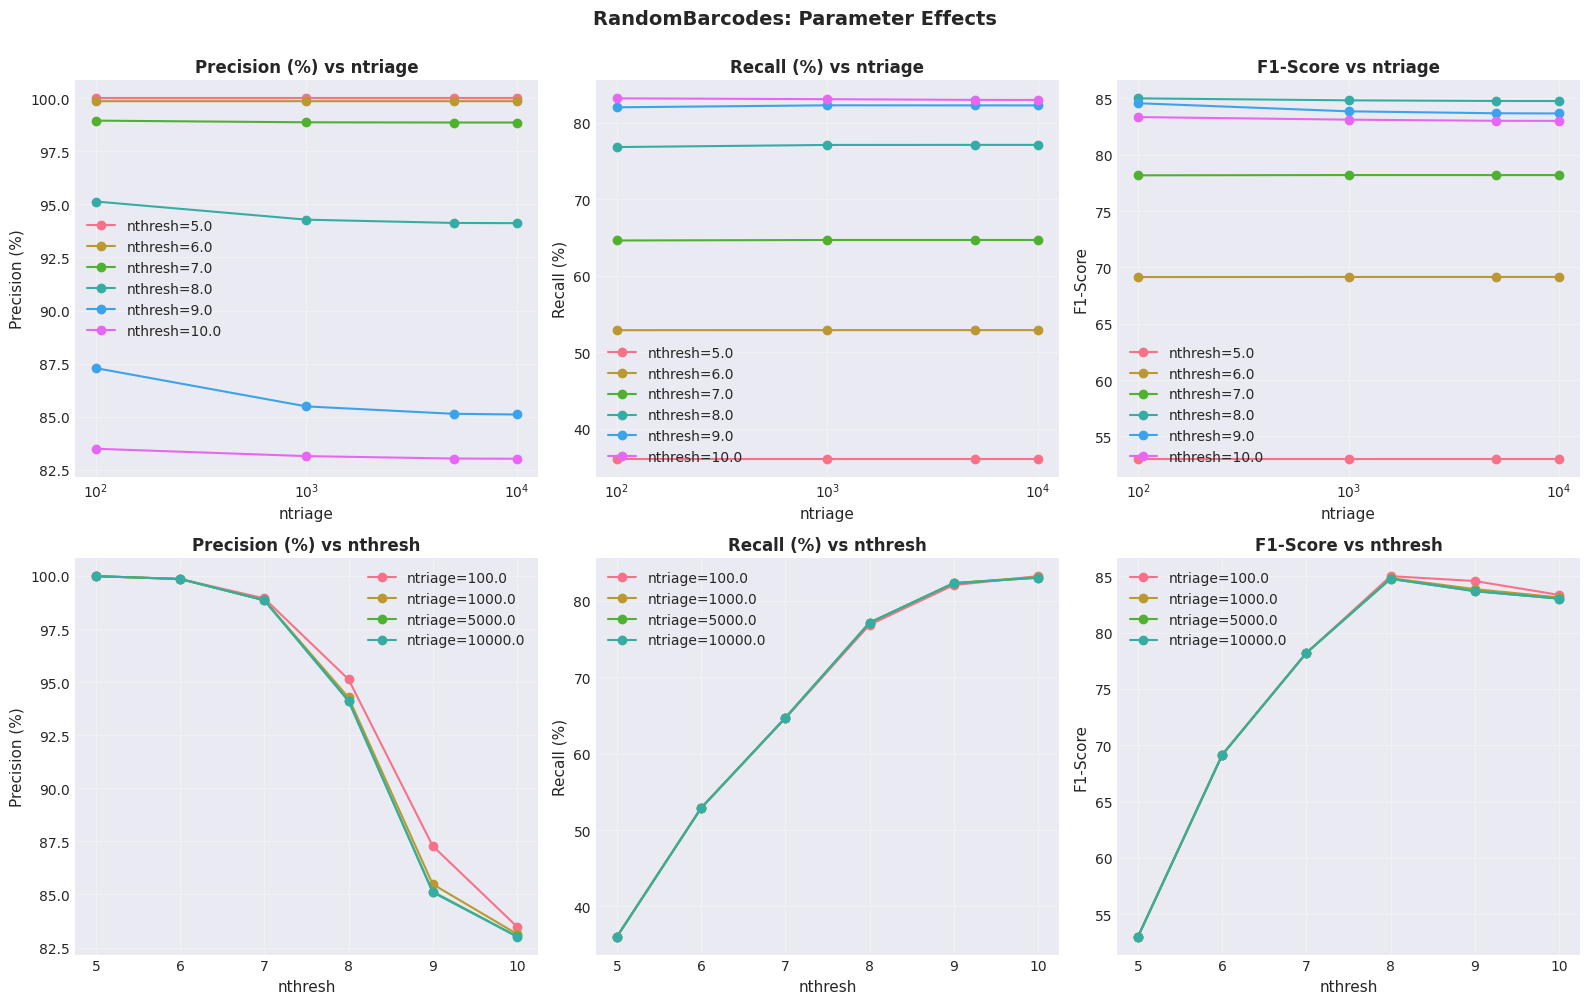

In [31]:
# RandomBarcodes: Effect of ntriage and nthresh
if df_rb is not None:
    # Convert to numeric
    df_rb['ntriage'] = pd.to_numeric(df_rb['ntriage'])
    df_rb['nthresh'] = pd.to_numeric(df_rb['nthresh'])
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    metrics = ['precision', 'recall', 'f1_score']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score']
    
    # Plot by ntriage
    for ax, metric, title in zip(axes[0], metrics, titles):
        for nthresh in sorted(df_rb['nthresh'].unique()):
            data = df_rb[df_rb['nthresh'] == nthresh].sort_values('ntriage')
            ax.plot(data['ntriage'], data[metric], marker='o', label=f'nthresh={nthresh}')
        ax.set_xlabel('ntriage', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs ntriage', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.set_xscale('log')
    
    # Plot by nthresh
    for ax, metric, title in zip(axes[1], metrics, titles):
        for ntriage in sorted(df_rb['ntriage'].unique()):
            data = df_rb[df_rb['ntriage'] == ntriage].sort_values('nthresh')
            ax.plot(data['nthresh'], data[metric], marker='o', label=f'ntriage={ntriage}')
        ax.set_xlabel('nthresh', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs nthresh', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.suptitle('RandomBarcodes: Parameter Effects', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figures/randombarcodes_parameters.png', dpi=300, bbox_inches='tight')
    plt.show()

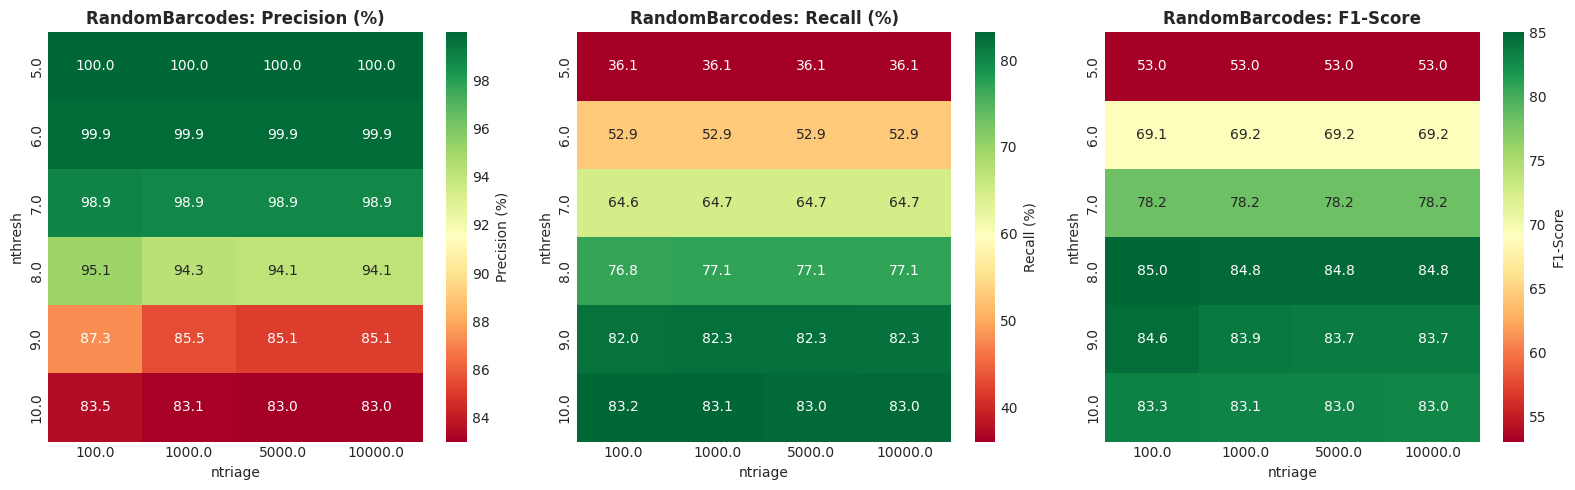

In [32]:
# RandomBarcodes: Heatmaps
if df_rb is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, metric, title in zip(axes, ['precision', 'recall', 'f1_score'],
                                  ['Precision (%)', 'Recall (%)', 'F1-Score']):
        pivot = df_rb.pivot(index='nthresh', columns='ntriage', values=metric)
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, cbar_kws={'label': title})
        ax.set_title(f'RandomBarcodes: {title}', fontweight='bold')
        ax.set_xlabel('ntriage')
        ax.set_ylabel('nthresh')
    
    plt.tight_layout()
    plt.savefig('figures/randombarcodes_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5. QUIK Parameter Analysis

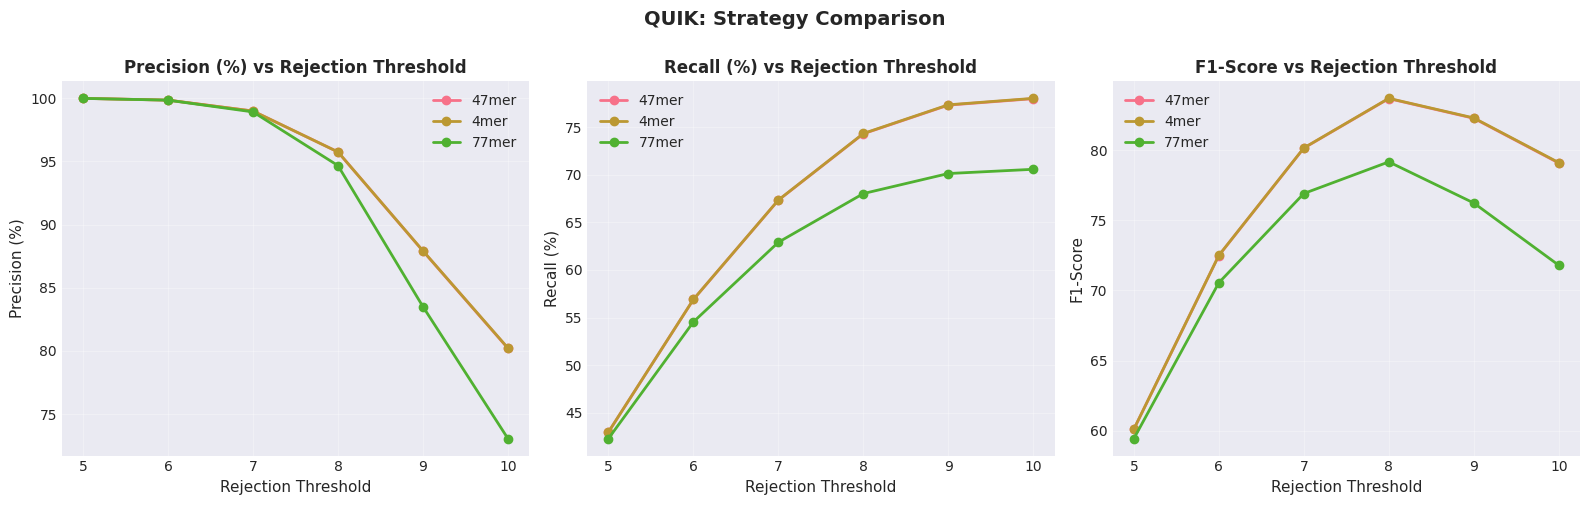

In [33]:
# QUIK: Effect of strategy and rejection_threshold
if df_quik is not None:
    df_quik['rejection_threshold'] = pd.to_numeric(df_quik['rejection_threshold'])
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['precision', 'recall', 'f1_score']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score']
    
    for ax, metric, title in zip(axes, metrics, titles):
        for strategy in sorted(df_quik['strategy'].unique()):
            data = df_quik[df_quik['strategy'] == strategy].sort_values('rejection_threshold')
            ax.plot(data['rejection_threshold'], data[metric], marker='o', label=strategy, linewidth=2)
        ax.set_xlabel('Rejection Threshold', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs Rejection Threshold', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.suptitle('QUIK: Strategy Comparison', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figures/quik_parameters.png', dpi=300, bbox_inches='tight')
    plt.show()

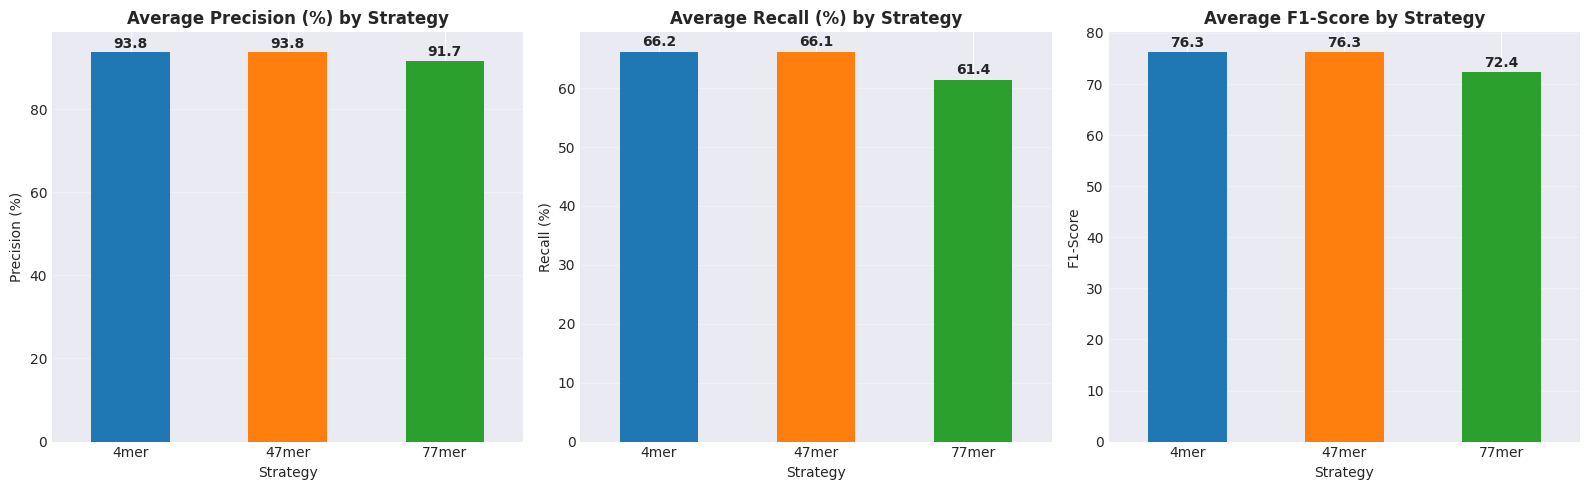

In [34]:
# QUIK: Bar plot comparison by strategy
if df_quik is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, metric, title in zip(axes, ['precision', 'recall', 'f1_score'],
                                  ['Precision (%)', 'Recall (%)', 'F1-Score']):
        strategy_avg = df_quik.groupby('strategy')[metric].mean().sort_values(ascending=False)
        strategy_avg.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax.set_title(f'Average {title} by Strategy', fontweight='bold')
        ax.set_xlabel('Strategy')
        ax.set_ylabel(title)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(strategy_avg.values):
            ax.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/quik_strategy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

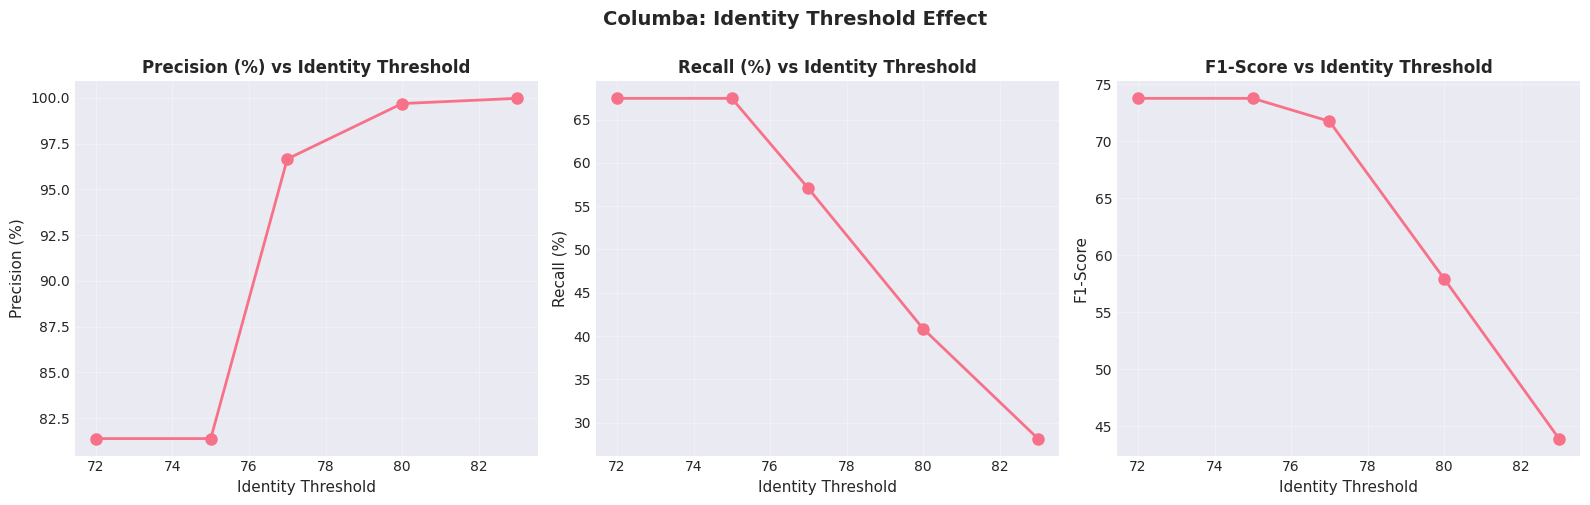

In [35]:
# Columba: Effect of identity_threshold
if df_columba is not None:
    df_columba['identity_threshold'] = pd.to_numeric(df_columba['identity_threshold'])
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['precision', 'recall', 'f1_score']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score']
    
    for ax, metric, title in zip(axes, metrics, titles):
        data = df_columba.sort_values('identity_threshold')
        ax.plot(data['identity_threshold'], data[metric], marker='o', linewidth=2, markersize=8)
        ax.set_xlabel('Identity Threshold', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs Identity Threshold', fontweight='bold')
        ax.grid(alpha=0.3)
    
    plt.suptitle('Columba: Identity Threshold Effect', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figures/columba_parameters.png', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Columba Parameter Analysis

## 6. Precision-Recall Trade-off

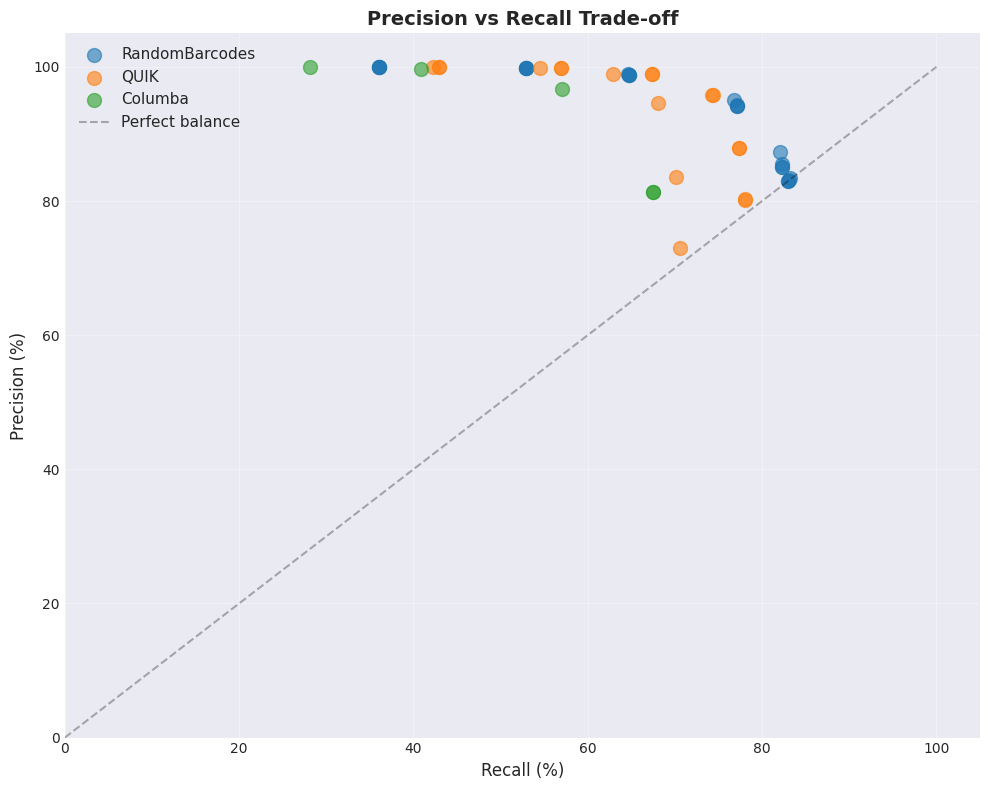

In [36]:
# Precision vs Recall scatter plot
if df_all is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = {'RandomBarcodes': '#1f77b4', 'QUIK': '#ff7f0e', 'Columba': '#2ca02c'}
    
    for tool in df_all['tool'].unique():
        data = df_all[df_all['tool'] == tool]
        ax.scatter(data['recall'], data['precision'], 
                  label=tool, alpha=0.6, s=100, color=colors.get(tool, 'gray'))
    
    # Add diagonal line (perfect precision-recall)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect balance')
    
    ax.set_xlabel('Recall (%)', fontsize=12)
    ax.set_ylabel('Precision (%)', fontsize=12)
    ax.set_title('Precision vs Recall Trade-off', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 105)
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    plt.savefig('figures/precision_recall_tradeoff.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Assignment Rate Analysis

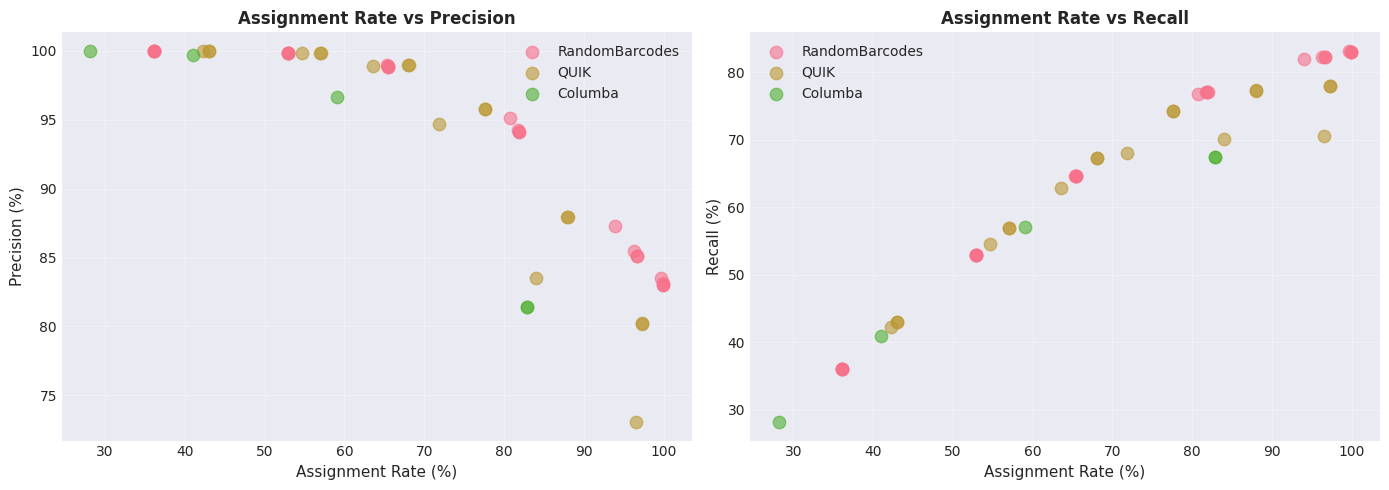

In [37]:
# Assignment rate vs metrics
if df_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for tool in df_all['tool'].unique():
        data = df_all[df_all['tool'] == tool]
        axes[0].scatter(data['assignment_rate'], data['precision'], 
                       label=tool, alpha=0.6, s=80)
        axes[1].scatter(data['assignment_rate'], data['recall'], 
                       label=tool, alpha=0.6, s=80)
    
    axes[0].set_xlabel('Assignment Rate (%)', fontsize=11)
    axes[0].set_ylabel('Precision (%)', fontsize=11)
    axes[0].set_title('Assignment Rate vs Precision', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].set_xlabel('Assignment Rate (%)', fontsize=11)
    axes[1].set_ylabel('Recall (%)', fontsize=11)
    axes[1].set_title('Assignment Rate vs Recall', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/assignment_rate_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Top Performing Configurations


=== Top 10 Configurations (by F1-score) ===


,tool,sample_id,precision,recall,f1_score,assignment_rate
16,RandomBarcodes,RB_t100_n8,95.130604,76.8270,85.004661,80.7595
10,RandomBarcodes,RB_t1000_n8,94.276893,77.1020,84.828848,81.7825
22,RandomBarcodes,RB_t5000_n8,94.122637,77.1095,84.770880,81.9245
4,RandomBarcodes,RB_t10000_n8,94.111724,77.1095,84.766454,81.9340
17,RandomBarcodes,RB_t100_n9,87.286233,82.0220,84.572277,93.9690
11,RandomBarcodes,RB_t1000_n9,85.484399,82.2860,83.854712,96.2585
34,QUIK,QUIK_4mer_r8,95.747353,74.3325,83.691748,77.6340
23,RandomBarcodes,RB_t5000_n9,85.136359,82.2745,83.680968,96.6385
28,QUIK,QUIK_47mer_r8,95.745257,74.3055,83.673831,77.6075
5,RandomBarcodes,RB_t10000_n9,85.103181,82.2735,83.664421,96.6750


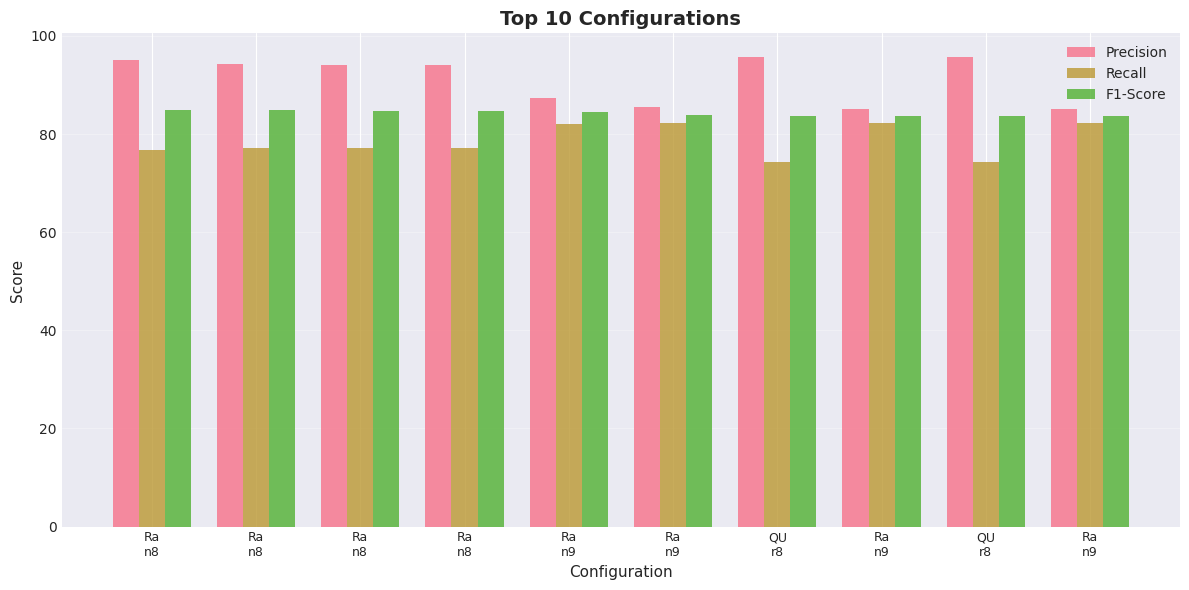

In [38]:
# Top 10 configurations by F1-score
if df_all is not None:
    print("\n=== Top 10 Configurations (by F1-score) ===")
    top10 = df_all.nlargest(10, 'f1_score')[['tool', 'sample_id', 'precision', 'recall', 'f1_score', 'assignment_rate']]
    display(top10)
    
    # Visualize top 10
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(top10))
    width = 0.25
    
    ax.bar([i - width for i in x], top10['precision'], width, label='Precision', alpha=0.8)
    ax.bar(x, top10['recall'], width, label='Recall', alpha=0.8)
    ax.bar([i + width for i in x], top10['f1_score'], width, label='F1-Score', alpha=0.8)
    
    ax.set_xlabel('Configuration', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Top 10 Configurations', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['tool'][:2]}\n{row['sample_id'].split('_')[-1]}" 
                        for _, row in top10.iterrows()], rotation=0, fontsize=9)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/top10_configurations.png', dpi=300, bbox_inches='tight')
    plt.show()

## 9. Export Summary Report

In [39]:
# Create summary report
if df_all is not None:
    report = []
    report.append("="*80)
    report.append("PARAMETER SWEEP ANALYSIS SUMMARY - 28nt Barcodes")
    report.append("="*80)
    report.append("")
    report.append(f"Dataset: 21,000 barcodes (28nt), 200,000 simulated reads")
    report.append(f"Total configurations tested: {len(df_all)}")
    report.append("")
    
    report.append("-"*80)
    report.append("OVERALL PERFORMANCE BY TOOL")
    report.append("-"*80)
    for tool in df_all['tool'].unique():
        tool_data = df_all[df_all['tool'] == tool]
        report.append(f"\n{tool}:")
        report.append(f"  Configurations: {len(tool_data)}")
        report.append(f"  Avg Precision:  {tool_data['precision'].mean():.2f}% (±{tool_data['precision'].std():.2f})")
        report.append(f"  Avg Recall:     {tool_data['recall'].mean():.2f}% (±{tool_data['recall'].std():.2f})")
        report.append(f"  Avg F1-Score:   {tool_data['f1_score'].mean():.2f} (±{tool_data['f1_score'].std():.2f})")
        report.append(f"  Avg Assign Rate: {tool_data['assignment_rate'].mean():.2f}%")
    
    report.append("")
    report.append("-"*80)
    report.append("BEST CONFIGURATION PER TOOL (by F1-score)")
    report.append("-"*80)
    for tool in df_all['tool'].unique():
        tool_data = df_all[df_all['tool'] == tool]
        best = tool_data.loc[tool_data['f1_score'].idxmax()]
        report.append(f"\n{tool}: {best['sample_id']}")
        report.append(f"  Precision:  {best['precision']:.2f}%")
        report.append(f"  Recall:     {best['recall']:.2f}%")
        report.append(f"  F1-Score:   {best['f1_score']:.2f}")
        report.append(f"  Assign Rate: {best['assignment_rate']:.2f}%")
    
    report.append("")
    report.append("="*80)
    
    # Print report
    report_text = "\n".join(report)
    print(report_text)
    
    # Save report
    with open('summary_report.txt', 'w') as f:
        f.write(report_text)
    
    print("\n✓ Summary report saved to: summary_report.txt")

PARAMETER SWEEP ANALYSIS SUMMARY - 28nt Barcodes

Dataset: 21,000 barcodes (28nt), 200,000 simulated reads
Total configurations tested: 47

--------------------------------------------------------------------------------
OVERALL PERFORMANCE BY TOOL
--------------------------------------------------------------------------------

RandomBarcodes:
  Configurations: 24
  Avg Precision:  93.68% (±6.98)
  Avg Recall:     65.99% (±17.42)
  Avg F1-Score:   75.38 (±11.57)
  Avg Assign Rate: 71.97%

QUIK:
  Configurations: 18
  Avg Precision:  93.08% (±8.67)
  Avg Recall:     64.57% (±12.41)
  Avg F1-Score:   74.99 (±8.02)
  Avg Assign Rate: 70.81%

Columba:
  Configurations: 5
  Avg Precision:  91.82% (±9.61)
  Avg Recall:     52.19% (±17.29)
  Avg F1-Score:   64.23 (±13.13)
  Avg Assign Rate: 58.78%

--------------------------------------------------------------------------------
BEST CONFIGURATION PER TOOL (by F1-score)
-------------------------------------------------------------------------

In [40]:
df_all.head()

,tool,sample_id,identity_threshold,nthresh,ntriage,rejection_threshold,strategy,total_reads,correct,incorrect,unassigned,assignment_rate,precision,recall,accuracy,f1_score
0,RandomBarcodes,RB_t10000_n10,NaN,10.0,10000.0,NaN,NaN,200000,165970,33948,82,99.9590,83.019038,82.9850,82.9850,83.002015
1,RandomBarcodes,RB_t10000_n5,NaN,5.0,10000.0,NaN,NaN,200000,72138,8,127854,36.0730,99.988911,36.0690,36.0690,53.014191
2,RandomBarcodes,RB_t10000_n6,NaN,6.0,10000.0,NaN,NaN,200000,105777,153,94070,52.9650,99.855565,52.8885,52.8885,69.151113
3,RandomBarcodes,RB_t10000_n7,NaN,7.0,10000.0,NaN,NaN,200000,129356,1503,69141,65.4295,98.851436,64.6780,64.6780,78.194034
4,RandomBarcodes,RB_t10000_n8,NaN,8.0,10000.0,NaN,NaN,200000,154219,9649,36132,81.9340,94.111724,77.1095,77.1095,84.766454


## 10. Precision-Recall Curves by Barcode Length

Loaded 36nt data: 38 samples


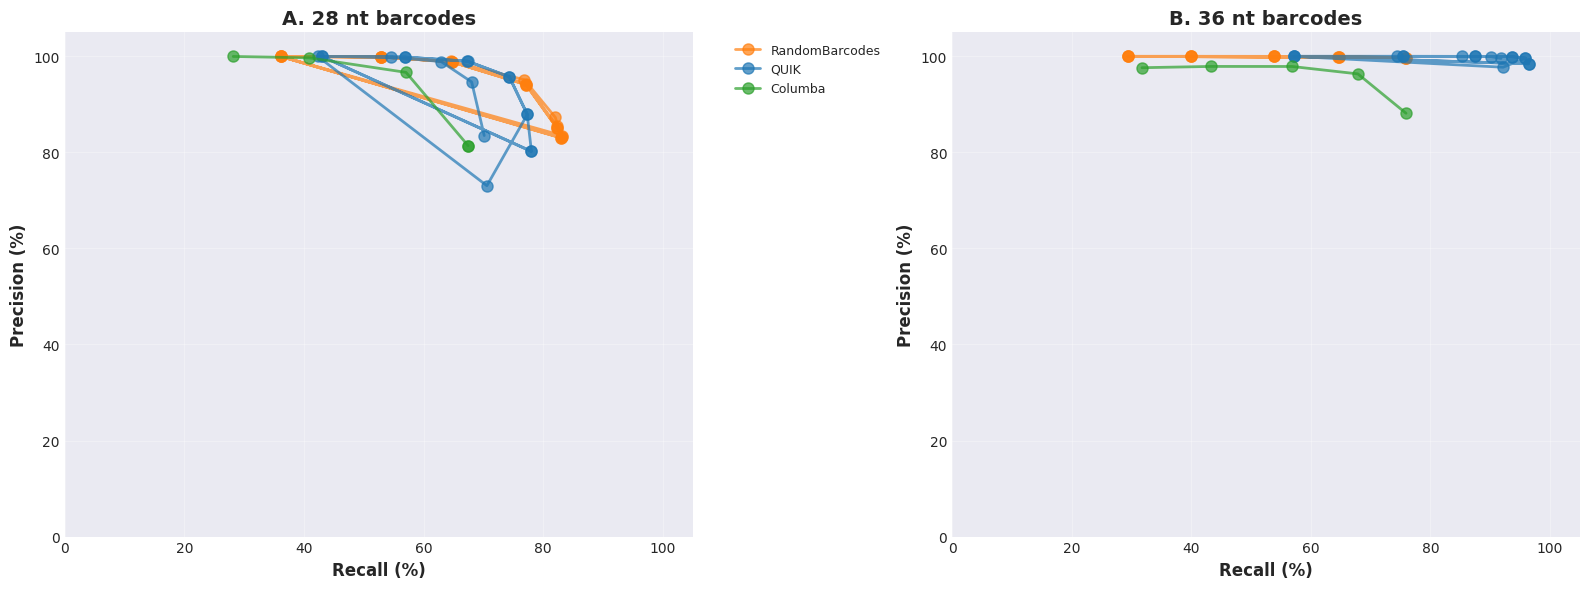


✓ Precision-Recall curves saved to: figures/precision_recall_curves.png


In [41]:
# Precision-Recall Curves for 28nt and 36nt Barcodes
# Load data for both barcode lengths
import matplotlib.pyplot as plt
import seaborn as sns

# Load 28nt data (already loaded as df_all)
# Load 36nt data
data_file_36nt = Path("/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_36nt/summaries/all_corrected_metrics.csv")

# Check if 36nt file exists, otherwise try alternative paths
if not data_file_36nt.exists():
    # Try alternative path
    data_file_36nt = Path("/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep/results_36nt/summaries/all_corrected_metrics.csv")

# Load 36nt data if available
if data_file_36nt.exists():
    df_36nt = pd.read_csv(data_file_36nt)
    print(f"Loaded 36nt data: {len(df_36nt)} samples")
else:
    print(f"36nt data not found, will only plot 28nt data")
    df_36nt = None

# Combine datasets with barcode length labels
if df_all is not None:
    df_28nt = df_all.copy()
    df_28nt['barcode_length'] = 28
    
    if df_36nt is not None:
        df_36nt['barcode_length'] = 36
        df_combined = pd.concat([df_28nt, df_36nt], ignore_index=True)
    else:
        df_combined = df_28nt
    
    # Create the precision-recall curves plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Define colors for each tool
    tool_colors = {
        'QUIK': '#1f77b4',
        'RandomBarcodes': '#ff7f0e',
        'Columba': '#2ca02c'
    }
    
    # Define markers for different threshold values
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    
    barcode_lengths = [28, 36] if df_36nt is not None else [28]
    panel_labels = ['A', 'B']
    
    for idx, (barcode_len, ax, label) in enumerate(zip(barcode_lengths, axes.flat, panel_labels)):
        # Filter data for this barcode length
        df_length = df_combined[df_combined['barcode_length'] == barcode_len]
        
        # Plot for each tool
        for tool in df_length['tool'].unique():
            df_tool = df_length[df_length['tool'] == tool]
            
            # Get unique threshold values
            if 'threshold' in df_tool.columns:
                thresholds = sorted(df_tool['threshold'].unique())
                
                # Plot precision-recall curve with different markers for thresholds
                for i, threshold in enumerate(thresholds):
                    df_thresh = df_tool[df_tool['threshold'] == threshold]
                    marker = markers[i % len(markers)]
                    
                    ax.plot(df_thresh['recall'], df_thresh['precision'], 
                           marker=marker, 
                           color=tool_colors.get(tool, 'gray'),
                           label=f"{tool} (t={threshold})" if idx == 0 else "",
                           linewidth=2,
                           markersize=8,
                           alpha=0.7)
            else:
                # If no threshold column, just plot all points
                ax.plot(df_tool['recall'], df_tool['precision'], 
                       marker='o',
                       color=tool_colors.get(tool, 'gray'),
                       label=tool if idx == 0 else "",
                       linewidth=2,
                       markersize=8,
                       alpha=0.7)
        
        # Formatting
        ax.set_xlabel('Recall (%)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Precision (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{label}. {barcode_len} nt barcodes', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 105])
        ax.set_ylim([0, 105])
        
        # Add legend only to first panel
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    # Hide second axis if only one barcode length
    if df_36nt is None:
        axes[1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('figures/precision_recall_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Precision-Recall curves saved to: figures/precision_recall_curves.png")
else:
    print("ERROR: Data not available for plotting")

## 10. Key Findings

### RandomBarcodes:
- **ntriage effect**: Higher values generally improve precision but may reduce recall
- **nthresh effect**: Lower values increase recall but reduce precision
- **Trade-off**: Balance between precision and recall depends on use case

### QUIK:
- **Strategy comparison**: Different k-mer strategies show varying performance
- **Rejection threshold**: Higher values increase precision, lower values increase recall
- **Optimal strategy**: Depends on precision/recall requirements

### Overall:
- Both tools show strong performance with proper parameter tuning
- Parameter selection should be guided by application requirements
- Assignment rate is generally high (>90%) for most configurations